# LLaVADataset

## pretrianing

In [ ]:
import json
import os
import sys

with open('/data/hyz/RAT/dataset/text_files/blip_laion_cc_sbu_558k.json', 'r') as f:
    pretrain = json.load(f)

In [ ]:
len(pretrain)


In [ ]:
pretrain[0]

In [ ]:
path = '/data/hyz/RAT/dataset/llava/llava_pretrain/images/'+pretrain[0]['image']

In [ ]:
from PIL import Image
img = Image.open(path)

In [ ]:
img

In [ ]:
conv = pretrain[0]['conversations']

In [ ]:
conv

In [ ]:
conv[1]['value']

In [ ]:
for i in range(10000):
    if len(pretrain[i]['conversations']) > 2:
        print(pretrain[i]['conversations'])

## finetune

In [ ]:
import json 
with open('/data/hyz/RAT/dataset/text_files/llava_v1_5_mix665k.json', 'r') as f:
    finetune = json.load(f)
len(finetune)

In [ ]:
finetune[0]

In [ ]:
from PIL import Image
Image.open('/data/hyz/RAT/dataset/' + finetune[0]['image'])

# ShareGPT4V Dataset

In [ ]:
with open('/data/hyz/RAT/dataset/text_files/share-captioner_coco_lcs_sam_1246k_1107.json', 'r') as f:
    sharegpt4v = json.load(f)
len(sharegpt4v), sharegpt4v[0], sharegpt4v[0]['conversations']


In [ ]:
# Image.open('/data/hyz/RAT/dataset/'+ sharegpt4v[0]['image'])
Image.open('/data/hyz/RAT/dataset/'+'sam/images/sa_1.jpg')

In [ ]:
for i in range(10000):
    if len(sharegpt4v[i]['conversations']) > 2:
        print(sharegpt4v[i]['conversations'])


# build memory


In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import json
import os
import sys

with open('/data/hyz/RAT/dataset/text_files/blip_laion_cc_sbu_558k.json', 'r') as f:
    pretrain = json.load(f)
# 指定设备为卡6
device = torch.device("cuda:6" if torch.cuda.is_available() else "cpu")

hf_path = '/data/hyz/RAT/checkpoints/tinyllava-phi'
model = AutoModelForCausalLM.from_pretrained(hf_path, trust_remote_code=True)
model.to(device)
config = model.config
tokenizer = AutoTokenizer.from_pretrained(hf_path, use_fast=False, model_max_length = config.tokenizer_model_max_length,padding_side = config.tokenizer_padding_side)


/data/hyz/.conda/envs/tinyllava/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.02it/s]
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [ ]:
import dataclasses
from enum import auto, Enum
from typing import List, Optional

class SeparatorStyle(Enum):
    """Different separator style."""
    SINGLE = auto()
    TWO = auto()
    MPT = auto()
    PLAIN = auto()
    LLAMA_2 = auto()
    TINY_LLAMA = auto()
    QWEN_2 = auto()

@dataclasses.dataclass
class Conversation:
    """A class that keeps all conversation history."""
    system: str
    roles: List[str]
    messages: List[List[str]]
    offset: int
    sep_style: SeparatorStyle = SeparatorStyle.SINGLE
    sep: str = "###"
    sep2: str = None
    version: str = "Unknown"

    skip_next: bool = False

    def get_prompt(self):
        messages = self.messages
        if len(messages) > 0 and type(messages[0][1]) is tuple:
            messages = self.messages.copy()
            init_role, init_msg = messages[0].copy()
            init_msg = init_msg[0].replace("<image>", "").strip()
            if 'mmtag' in self.version:
                messages[0] = (init_role, init_msg)
                messages.insert(0, (self.roles[0], "<Image><image></Image>"))
                messages.insert(1, (self.roles[1], "Received."))
            else:
                messages[0] = (init_role, "<image>\n" + init_msg)

        if self.sep_style == SeparatorStyle.TWO:
            seps = [self.sep, self.sep2]
            ret = self.system + seps[0]
            for i, (role, message) in enumerate(messages):
                if message:
                    if type(message) is tuple:
                        message, _, _ = message
                    ret += role + ": " + message + seps[i % 2]
                else:
                    ret += role + ":"
        else:
            raise ValueError(f"Invalid style: {self.sep_style}")

        return ret

    def append_message(self, role, message):
        self.messages.append([role, message])

    def copy(self):
        return Conversation(
            system=self.system,
            roles=self.roles,
            messages=[[x, y] for x, y in self.messages],
            offset=self.offset,
            sep_style=self.sep_style,
            sep=self.sep,
            sep2=self.sep2,
            version=self.version)



conv_phi_v0 = Conversation(
    system="A chat between a curious user and an artificial intelligence assistant. "
           "The assistant gives helpful, detailed, and polite answers to the user's questions.",
    roles=("USER", "ASSISTANT"),
    version="phi",
    messages=(),
    offset=0,
    sep_style=SeparatorStyle.TWO,
    sep=" ",
    sep2="<|endoftext|>",
)

In [ ]:
from PIL import Image
image = '/data/hyz/RAT/dataset/llava/llava_pretrain/images/'+pretrain[0]['image']
prompt = 'please describe the img.'
caption = pretrain[0]['conversations'][1]['value']

image_processor = model.vision_tower._image_processor

def expand2square(pil_img, background_color):
    width, height = pil_img.size
    if width == height:
        return pil_img
    elif width > height:
        result = Image.new(pil_img.mode, (width, width), background_color)
        result.paste(pil_img, (0, (width - height) // 2))
        return result
    else:
        result = Image.new(pil_img.mode, (height, height), background_color)
        result.paste(pil_img, ((height - width) // 2, 0))
        return result
    
def process_images(images, image_processor, model_cfg):
    image_aspect_ratio = getattr(model_cfg, "image_aspect_ratio", None)
    new_images = []
    if image_aspect_ratio == 'pad':
        for image in images:
            image = expand2square(image, tuple(int(x*255) for x in image_processor.image_mean))
            image = image_processor.preprocess(image, return_tensors='pt')['pixel_values'][0]
            new_images.append(image)
    else:
        return image_processor(images, return_tensors='pt')['pixel_values']
    if all(x.shape == new_images[0].shape for x in new_images):
        new_images = torch.stack(new_images, dim=0)
    return new_images

if image is not None:
    prompt = "<image>" + '\n' + prompt 

def tokenizer_image_token(prompt, tokenizer, image_token_index=-200, return_tensors=None):
    prompt_chunks = [tokenizer(chunk).input_ids for chunk in prompt.split('<image>')]

    def insert_separator(X, sep):
        return [ele for sublist in zip(X, [sep]*len(X)) for ele in sublist][:-1]

    input_ids = []
    offset = 0
    if len(prompt_chunks) > 0 and len(prompt_chunks[0]) > 0 and prompt_chunks[0][0] == tokenizer.bos_token_id:
        offset = 1
        input_ids.append(prompt_chunks[0][0])

    for x in insert_separator(prompt_chunks, [image_token_index] * (offset + 1)):
        input_ids.extend(x[offset:])

    if return_tensors is not None:
        if return_tensors == 'pt':
            return torch.tensor(input_ids, dtype=torch.long)
        raise ValueError(f'Unsupported tensor type: {return_tensors}')
    return input_ids

conv = conv_phi_v0.copy()
conv.append_message(conv.roles[0], prompt)
conv.append_message(conv.roles[1], None)
prompt = conv.get_prompt()
if image is not None:
    image = Image.open(image).convert("RGB")
    image_tensor = process_images(image, image_processor, model.config).to(model.device)

input_ids = (
    tokenizer_image_token(prompt, tokenizer, -200, return_tensors="pt")
    .unsqueeze(0).to(model.device)
)

In [4]:
image, image_tensor.shape

(<PIL.Image.Image image mode=RGB size=336x336>, torch.Size([1, 3, 384, 384]))

In [5]:
input_ids

tensor([[   32,  8537,  1022,   257, 11040,  2836,   290,   281, 11666,  4430,
          8796,    13,   383,  8796,  3607,  7613,    11,  6496,    11,   290,
         23507,  7429,   284,   262,  2836,   338,  2683,    13,  1294,  1137,
            25,   220,  -200,   198, 29688,  6901,   262, 33705,    13, 24994,
          8808,  8643,    25]], device='cuda:6')

In [6]:
prompt

"A chat between a curious user and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the user's questions. USER: <image>\nplease describe the img. ASSISTANT:"

In [7]:
tokenizer_image_token(prompt, tokenizer, -200, return_tensors="pt")

tensor([   32,  8537,  1022,   257, 11040,  2836,   290,   281, 11666,  4430,
         8796,    13,   383,  8796,  3607,  7613,    11,  6496,    11,   290,
        23507,  7429,   284,   262,  2836,   338,  2683,    13,  1294,  1137,
           25,   220,  -200,   198, 29688,  6901,   262, 33705,    13, 24994,
         8808,  8643,    25])

In [8]:
len(pretrain)

558128

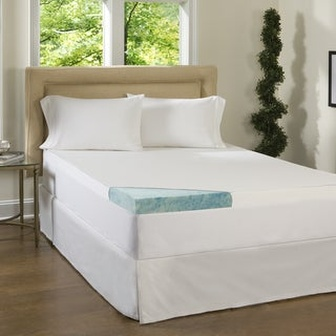

In [9]:
image

In [10]:
# import torch.nn as nn
# import torch
# from transformers.models.perceiver.modeling_perceiver import PerceiverTextPreprocessor
# from transformers.models.perceiver.modeling_perceiver import PerceiverImagePreprocessor
# from transformers.models.perceiver.modeling_perceiver import PerceiverMultimodalPreprocessor
# from transformers.models.perceiver.modeling_perceiver import PerceiverEncoder
# from transformers.models.perceiver.modeling_perceiver import PerceiverEmbeddings
# from transformers.models.perceiver.modeling_perceiver import PerceiverConfig

# class PerceiverMultiModalEncoder(nn.Module):
#     def __init__(self, config):
#         super().__init__()
        
#         # 创建图像和文本的预处理器
#         image_preprocessor = PerceiverImagePreprocessor(
#             config,
#             prep_type="conv1x1",  # 使用1x1卷积处理图像
#             spatial_downsample=1,
#             out_channels=256,
#             position_encoding_type="trainable",
#             concat_or_add_pos="concat",
#             project_pos_dim=256,
#             trainable_position_encoding_kwargs=dict(
#                 num_channels=256,
#                 index_dims=config.image_size**2,
#             ),
#         )
        
#         text_preprocessor = PerceiverTextPreprocessor(config)
        
#         # 创建多模态预处理器
#         self.preprocessor = PerceiverMultimodalPreprocessor(
#             modalities={
#                 "image": image_preprocessor,
#                 "text": text_preprocessor
#             },
#             min_padding_size=4
#         )
        
#         # 创建Perceiver编码器
#         self.embeddings = PerceiverEmbeddings(config)
#         self.encoder = PerceiverEncoder(
#             config,
#             kv_dim=self.preprocessor.num_channels
#         )
        
#     def forward(self, inputs):
#         """
#         Args:
#             inputs: 字典,包含:
#                 - image: shape (batch_size, channels, height, width)
#                 - text: shape (batch_size, sequence_length)
                
#         Returns:
#             latent: shape (batch_size, num_latents, d_latents)
#         """
#         # 1. 预处理输入
#         processed_inputs, _, _ = self.preprocessor(inputs)
        
#         # 2. 获取latent的初始值
#         batch_size = processed_inputs.shape[0]
#         latent = self.embeddings(batch_size)
#         print(latent.shape)
#         # 3. 通过编码器获取最终的latent表示
#         encoder_outputs = self.encoder(
#             latent,
#             inputs=processed_inputs,
#         )
        
#         # 返回最后一层的latent表示
#         return encoder_outputs[0]  # shape: (batch_size, num_latents, d_latents)

# # 使用示例:

# # 1. 配置
# config = PerceiverConfig(
#     num_latents=256,          # latent序列的长度
#     d_latents=512,           # latent的维度
#     d_model=256,             # 预处理后的输入维度
#     num_self_attends_per_block=8,  # self-attention层数
#     num_blocks=1,            # 编码器block数量
#     num_self_attention_heads=8,    # self-attention的头数
#     num_cross_attention_heads=8,   # cross-attention的头数
#     qk_channels=512,         # 添加这个参数，确保能被8整除
#     v_channels=512, 
#     image_size=224,          # 输入图像大小
#     vocab_size=30522,        # 词表大小
#     max_position_embeddings=512,  # 最大文本长度
# )

# # 2. 创建模型
# perceiver_model = PerceiverMultiModalEncoder(config)

# # 3. 准备输入数据
# inputs = {
#     "image": torch.randn(2, 3, 224, 224),  # 批量大小为2的图像
#     "text": torch.randint(0, config.vocab_size, (2, 128))  # 批量大小为2的文本
# }

# # 4. 获取latent表示
# latent = perceiver_model(inputs)
# print("Latent shape:", latent.shape)  
# # 预期输出: torch.Size([2, 256, 512])

# # 分别对应: [batch_size, num_latents, d_latents]



In [11]:
# perceiver_model.to('cuda:6')

In [12]:
# from transformers.models.perceiver.modeling_perceiver import *
# def create_multimodal_preprocessor(config):
#     # 图像预处理器
#     image_preprocessor = PerceiverImagePreprocessor(
#         config,
#         prep_type="conv1x1",  # 使用1x1卷积处理图像
#         spatial_downsample=1,
#         out_channels=256,
#         position_encoding_type="trainable",
#         concat_or_add_pos="concat",
#         project_pos_dim=256,
#         trainable_position_encoding_kwargs=dict(
#             num_channels=256,
#             index_dims=config.image_size**2,
#         ),
#     )
    
#     # 文本预处理器
#     text_preprocessor = PerceiverTextPreprocessor(config)
    
#     # 组合为多模态预处理器
#     multimodal_preprocessor = PerceiverMultimodalPreprocessor(
#         modalities={
#             "image": image_preprocessor,
#             "text": text_preprocessor
#         },
#         min_padding_size=4
#     )
    
#     return multimodal_preprocessor

# def create_multimodal_decoder(config):
#     # 图像解码器
#     image_decoder = PerceiverBasicDecoder(
#         config,
#         output_num_channels=config.d_latents,
#         output_index_dims=1,
#         num_channels=config.d_latents,
#         use_query_residual=True
#     )
    
#     # 文本解码器  
#     text_decoder = PerceiverBasicDecoder(
#         config,
#         output_num_channels=config.d_latents,
#         output_index_dims=1, 
#         num_channels=config.d_latents,
#         use_query_residual=True
#     )
    
#     # 组合为多模态解码器
#     multimodal_decoder = PerceiverMultimodalDecoder(
#         config,
#         modalities={
#             "image": image_decoder,
#             "text": text_decoder
#         },
#         num_outputs=config.num_latents,
#         output_num_channels=config.d_latents,
#         use_query_residual=False
#     )
    
#     return multimodal_decoder
# class PerceiverMultiModal(nn.Module):
#     def __init__(self, config):
#         super().__init__()
#         self.config = config
        
#         # 创建预处理器
#         self.preprocessor = create_multimodal_preprocessor(config)
        
#         # 移除这一行，因为在初始化时还没有inputs
#         # processed_inputs, modality_sizes, inputs_without_pos = self.preprocessor(inputs)
        
#         # 创建Perceiver编码器
#         self.encoder = PerceiverEncoder(
#             # config=config,
#             input_preprocessor=self.preprocessor,
            
#         )
        
#         # 创建解码器
#         self.decoder = create_multimodal_decoder(config)
        
#         # 创建后处理器
#         self.postprocessor = PerceiverMultimodalPostprocessor(
#             modalities={
#                 "image": PerceiverProjectionPostprocessor(
#                     in_channels=config.d_latents,
#                     out_channels=config.image_channels
#                 ),
#                 "text": PerceiverProjectionPostprocessor(
#                     in_channels=config.d_latents,
#                     out_channels=config.vocab_size
#                 )
#             }
#         )
        
#     def forward(self, inputs):
#         # 确保输入在正确的设备上
#         inputs = {k: v.to(next(self.parameters()).device) for k, v in inputs.items()}
        
#         # 1. 预处理
#         processed_inputs, modality_sizes, inputs_without_pos = self.preprocessor(inputs)
        
#         # 2. 编码 - 修改为正确的参数传递方式
#         encoder_outputs = self.encoder(
#             inputs=processed_inputs,
#             hidden_states=None
#         )
        
#         latent_repr = encoder_outputs.last_hidden_state
        
#         return latent_repr

# # 更新配置
# config = PerceiverConfig(
#     # 基础配置
#     num_latents=256,          # latent序列的长度
#     d_latents=512,           # latent的维度
#     d_model=256,             # 预处理后的输入维度
    
#     # 注意力相关配置
#     num_self_attends_per_block=8,  # self-attention层数
#     num_blocks=1,            # 编码器block数量
#     num_self_attention_heads=8,    # self-attention的头数
#     num_cross_attention_heads=8,   # cross-attention的头数
#     qk_channels=64,          # 注意力头的维度，确保能被头数整除
#     v_channels=64,           # 值的维度
    
#     # 图像相关配置
#     image_size=224,          # 输入图像大小
#     image_channels=3,        # 添加这个参数
    
#     # 文本相关配置
#     vocab_size=30522,        # 词表大小
#     max_position_embeddings=512,  # 最大文本长度
    
#     # 其他必要的配置
#     cross_attention_widening_factor=1,
#     self_attention_widening_factor=1,
#     use_query_residual=True
# )
# input_preprocessor.num_channels = config.image_channels  # 更新预处理器的通道数
# # 创建模型
# model = PerceiverMultiModal(config).to('cuda:6')

# # 准备输入
# inputs = {
#     "image": torch.randn(1, 3, 224, 224).to('cuda:6'),  # 移动到GPU
#     "text": torch.randint(0, config.vocab_size, (1, 128)).to('cuda:6')  # 移动到GPU
# }

# # 前向传播
# outputs = model(inputs)


In [ ]:

from torchvision import transforms
transform = transforms.Compose([
        transforms.Resize((224, 224)),  # 将图像调整为224x224
        # 如果需要，还可以添加其他预处理步骤
        # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
from transformers import PerceiverTokenizer, PerceiverForMultimodalAutoencoding, PerceiverConfig
config = PerceiverConfig.from_pretrained("/data/hyz/vlm/multimodal-perceiver")
tokenizer = PerceiverTokenizer.from_pretrained("/data/hyz/vlm/perceiver")
from transformers.models.perceiver.modeling_perceiver import *
def create_multimodal_preprocessor(config):
    # 图像预处理器
    image_preprocessor = PerceiverImagePreprocessor(
        config,
        prep_type="conv1x1",  # 使用1x1卷积处理图像
        spatial_downsample=1,
        out_channels=256,
        position_encoding_type="trainable",
        concat_or_add_pos="concat",
        project_pos_dim=256,
        trainable_position_encoding_kwargs=dict(
            num_channels=256,
            index_dims=config.image_size**2,
        ),
    )

    # 文本预处理器
    text_preprocessor = PerceiverTextPreprocessor(config)
    
    # 组合为多模态预处理器
    multimodal_preprocessor = PerceiverMultimodalPreprocessor(
        modalities={
            "image": image_preprocessor,
            "text": text_preprocessor
        },
        min_padding_size=4
    )
    
    return multimodal_preprocessor

device = model.device
multi_model = PerceiverForMultimodalAutoencoding.from_pretrained("/data/hyz/vlm/multimodal-perceiver").to(device)

multi_model.preprocessor = create_multimodal_preprocessor(config)


/data/hyz/.conda/envs/tinyllava/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


In [14]:
multi_model.preprocessor

PerceiverMultimodalPreprocessor(
  (modalities): ModuleDict(
    (image): PerceiverImagePreprocessor(
      (convnet_1x1): Conv2d(3, 256, kernel_size=(1, 1), stride=(1, 1))
      (position_embeddings): PerceiverTrainablePositionEncoding()
      (positions_projection): Linear(in_features=256, out_features=256, bias=True)
      (conv_after_patches): Identity()
    )
    (text): PerceiverTextPreprocessor(
      (embeddings): Embedding(262, 704)
      (position_embeddings): Embedding(2048, 704)
    )
  )
  (padding): ParameterDict(
      (image): Parameter containing: [torch.FloatTensor of size 1x196]
      (text): Parameter containing: [torch.FloatTensor of size 1x4]
  )
  (mask): ParameterDict()
)

In [15]:
perceiver_model = multi_model.perceiver

embedding_output = perceiver_model.embeddings(batch_size=1)


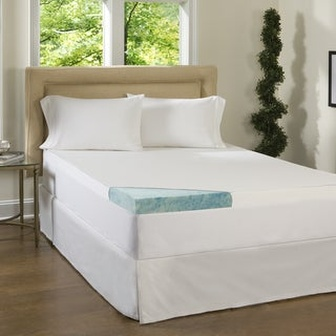

In [16]:
image

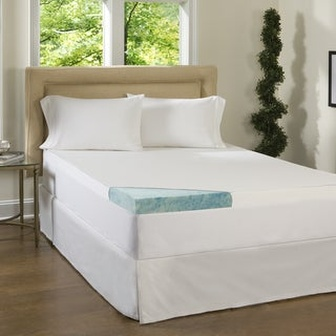

In [17]:
image

In [20]:
# perceiver_model = multi_model.perceiver(input_preprocessor=multi_model.preprocessor)

# embedding_output = perceiver_model.embeddings(batch_size=1)



memory = {}
for i in range(len(pretrain)):
    if i < 2:
        image = '/data/hyz/RAT/dataset/llava/llava_pretrain/images/'+pretrain[i]['image']
        image = Image.open(image).convert("RGB")
        image_tensor = process_images(image, image_processor, model.config).to(model.device)
        prompt = 'please describe the img.'
        caption = pretrain[i]['conversations'][1]['value']
        caption = '<image>\n' + ' the caption of the image is: ' + caption
        img_cap_token = tokenizer_image_token(caption, tokenizer, -200, return_tensors="pt")
        image_features = model.encode_images(image_tensor).squeeze(0).to(device)
        txt_embedding = model.language_model.model.embed_tokens(img_cap_token[1:].to(device))
        multimodal_features = torch.cat((image_features, txt_embedding), dim=0)
        value_caption = 'the caption of the image is: ' + caption
        encoding = tokenizer('the caption of the image is: ' + caption, padding="max_length", return_tensors="pt")
        # # mask " missing.". Note that the model performs much better if the masked span starts with a space.
        # encoding.input_ids[0, 52:61] = tokenizer.mask_token_id
        # inputs, input_mask = encoding.input_ids.to(device), encoding.attention_mask.to(device)
        inputs = {
            "image": transform(image),
            "text": value_caption,
        }
        
        


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [21]:
image = '/data/hyz/RAT/dataset/llava/llava_pretrain/images/'+pretrain[0]['image']
image = Image.open(image).convert("RGB")

In [23]:
image_tensor = process_images(image, image_processor, model.config).to(model.device)
image_tensor 

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [19]:
encoder_outputs = perceiver_model.encoder(
            embedding_output,
            attention_mask=None,
            inputs=inputs,
        )
sequence_output = encoder_outputs[0]
memory[multimodal_features] = sequence_output

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
encoding

In [ ]:
transform

In [ ]:
image_tensor.shape, image_tensor.dtype, image_tensor.device, 

In [ ]:
transform(image)

In [ ]:
inputs

In [ ]:
encoding

In [ ]:
from transformers import PerceiverTokenizer, PerceiverForMaskedLM
device = 'cuda:6'
tokenizer = PerceiverTokenizer.from_pretrained("/data/hyz/vlm/perceiver")
model = PerceiverForMaskedLM.from_pretrained("/data/hyz/vlm/perceiver")

text = "This is an incomplete sentence where some words are missing."
# prepare input
encoding = tokenizer(text, padding="max_length", return_tensors="pt")
# mask " missing.". Note that the model performs much better if the masked span starts with a space.
encoding.input_ids[0, 52:61] = tokenizer.mask_token_id
inputs, input_mask = encoding.input_ids.to(device), encoding.attention_mask.to(device)
model = model.to(device)
# forward pass
outputs = model(inputs=inputs, attention_mask=input_mask)
logits = outputs.logits
masked_tokens_predictions = logits[0, 51:61].argmax(dim=-1)
print(tokenizer.decode(masked_tokens_predictions))



In [ ]:
encoding = tokenizer(' the caption of the image is: ' + 'xxxxx', padding="max_length", return_tensors="pt")

In [ ]:
encoding.input_ids.shape, encoding.attention_mask.shape

In [ ]:
inputs = {
    "image": torch.randn(2, 3, 224, 224),  # 批量大小为2的图像
    "text": torch.randint(0, config.vocab_size, (2, 128))  # 批量大小为2的文本
}

In [ ]:
inputs['image'].shape, inputs['text'].shape

In [ ]:
img_cap_token[1:].shape, image_tensor.shape, img_cap_token[1:].unsqueeze(0).shape

In [ ]:
import torch
from transformers import PerceiverForMultimodalAutoencoding

# 指定设备为卡6
device = torch.device("cuda:5" if torch.cuda.is_available() else "cpu")

model = PerceiverForMultimodalAutoencoding.from_pretrained("/data/hyz/vlm/multimodal-perceiver").to(device)

model


In [ ]:
inputs = {
    "image": torch.randn(2, 3, 224, 224),  # 批量大小为2的图像
    "text": torch.randint(0, config.vocab_size, (2, 128))  # 批量大小为2的文本
}

In [ ]:
image, caption

In [ ]:
len(index), index[0].shape, index[1].shape

In [ ]:
caption

In [ ]:
caption = '<image>\n' + ' the caption of the image is: ' + caption

In [ ]:
caption

In [ ]:
img_cap_token = tokenizer_image_token(caption, tokenizer, -200, return_tensors="pt")
img_cap_token

In [ ]:
img_cap_token = tokenizer_image_token(caption, tokenizer, -200, return_tensors="pt")
img_cap_token

In [ ]:
image_features = model.encode_images(image_tensor)

In [ ]:
image_features.shape

In [ ]:
img_cap_token.device

In [ ]:
a = img_cap_token.to('cuda:6')

In [ ]:
caption

In [ ]:
txt_embedding = model.language_model.model.embed_tokens(img_cap_token[1:].to('cuda:6'))

In [ ]:
txt_embedding.shape

In [ ]:
image_features.squeeze(0).shape

In [ ]:
image_features = image_features.squeeze(0).to('cuda:6')
# 直接用input和multimodal_feature做内积。
multimodal_features = torch.cat((image_features, txt_embedding), dim=0)


In [ ]:
multimodal_features.shape

In [ ]:
model

In [ ]:
prompt="What are these?"
image_url="http://images.cocodataset.org/test-stuff2017/000000000001.jpg"
output_text, genertaion_time = model.chat(prompt=prompt, image=image_url, tokenizer=tokenizer)

print('model output:', output_text)
print('runing time:', genertaion_time)


In [ ]:
a = Image.open('/data/hyz/RAT/dataset/' + finetune[0]['image'])

In [ ]:
from transformers import SiglipVisionModel, SiglipImageProcessor
# 用来计算相似度，img-caption， 从而达到正负样本，对比学习的loss构建，更新vit和llm，就是更新 memory-index。
# 直接Perceiver 作为memory-value，memory-value作为输入， 通过CA，参与梯度计算，更新参数。
# memory-value, Perceiver(img, caption),让Perceiver的输出尽可能和memory-index相似，用loss来更新Perceiver。一个F番薯一个2番薯。

In [ ]:
model.vision_tower

In [ ]:
model.language_model

# Load Memory and retrieve


In [ ]:
import torch
mem = torch.load('/data/hyz/TinyLLaVA/LLaVA_Dataset_Memory_0.pt')

In [1]:
import torch
mem = torch.load('/data/hyz/TinyLLaVA/Compressed_Memory.pt')
sample_key = next(iter(mem.keys()))
print("特征维度:", sample_key.shape)       # 预期输出: (sequence_length, d_model)
print("潜在表示维度:", mem[sample_key].shape)  # 预期输出: (batch_size, num_latents, d_latents)

特征维度: torch.Size([1, 2560])
潜在表示维度: torch.Size([1, 32, 96])


In [1]:
import torch
mem = torch.load('/data/hyz/TinyLLaVA/Compressed_LLaVA_Dataset_Memory_100000.pt')
sample_key = next(iter(mem.keys()))
print("特征维度:", sample_key.shape)       # 预期输出: (sequence_length, d_model)
print("潜在表示维度:", mem[sample_key].shape)  # 预期输出: (batch_size, num_latents, d_latents)
import torch

def inspect_memory(memory_dict, max_samples=5):
    """
    可视化检查memory字典结构
    :param memory_dict: 加载的memory字典
    :param max_samples: 最大打印样本数（设为None则打印全部）
    """
    if not memory_dict:
        print("Memory字典为空!")
        return

    total_items = len(memory_dict)
    print(f"共存储 {total_items} 个键值对\n{'-'*40}")

    # 抽样检查前max_samples项
    for i, (key, value) in enumerate(memory_dict.items()):
        if max_samples and i >= max_samples:
            print(f"\n...已省略{total_items - max_samples}项...")
            break
        
        # 键值类型校验
        key_type = type(key).__name__
        value_type = type(value).__name__
        
        # 形状信息提取
        key_shape = key.shape if isinstance(key, torch.Tensor) else "N/A"
        value_shape = value.shape if isinstance(value, torch.Tensor) else "N/A"
        
        # 设备信息
        key_device = key.device if hasattr(key, 'device') else "N/A"
        value_device = value.device if hasattr(value, 'device') else "N/A"

        # 格式化输出
        print(f"索引: {i}\n"
              f"  Key => 类型: {key_type:<8} 形状: {str(key_shape):<20} 设备: {str(key_device)}\n"
              f"  Val => 类型: {value_type:<8} 形状: {str(value_shape):<20} 设备: {str(value_device)}\n"
              f"{'-'*40}")


# 使用示例
if __name__ == "__main__":
    # 加载memory数据（建议加载到CPU）
    memory = torch.load("/data/hyz/TinyLLaVA/Compressed_LLaVA_Dataset_Memory_100000.pt", map_location='cpu')
    
    # 检查前5项+统计
    inspect_memory(memory, max_samples=5) 


特征维度: torch.Size([1, 2560])
潜在表示维度: torch.Size([1, 32, 96])
共存储 100000 个键值对
----------------------------------------
索引: 0
  Key => 类型: Tensor   形状: torch.Size([1, 2560]) 设备: cpu
  Val => 类型: Tensor   形状: torch.Size([1, 32, 96]) 设备: cpu
----------------------------------------
索引: 1
  Key => 类型: Tensor   形状: torch.Size([1, 2560]) 设备: cpu
  Val => 类型: Tensor   形状: torch.Size([1, 32, 96]) 设备: cpu
----------------------------------------
索引: 2
  Key => 类型: Tensor   形状: torch.Size([1, 2560]) 设备: cpu
  Val => 类型: Tensor   形状: torch.Size([1, 32, 96]) 设备: cpu
----------------------------------------
索引: 3
  Key => 类型: Tensor   形状: torch.Size([1, 2560]) 设备: cpu
  Val => 类型: Tensor   形状: torch.Size([1, 32, 96]) 设备: cpu
----------------------------------------
索引: 4
  Key => 类型: Tensor   形状: torch.Size([1, 2560]) 设备: cpu
  Val => 类型: Tensor   形状: torch.Size([1, 32, 96]) 设备: cpu
----------------------------------------

...已省略99995项...


In [2]:
import torch
import torch.nn.functional as F
import random

query_key = torch.randn(1, 2560)

# 归一化键
def normalize(tensor):
    return F.normalize(tensor, dim=-1)
keys, values = [], []
# 计算余弦相似度
similarities = []
for idx, (key, value) in enumerate(memory.items()):
    # # 如果形状不同，需进行对齐（例如截断或补零）
    # if key.size(0) != query_key.size(0):
    #     if key.size(0) > query_key.size(0):
    #         print(f"截断键 {idx} 从 {key.size(0)} 到 {query_key.size(0)}")
    #         # key = key[-query_key.size(0):]
    #         num_to_remove = key.size(0) - query_key.size(0)
    
    #         # 随机选择要删除的行索引
    #         indices_to_remove = random.sample(range(728), num_to_remove)
    #         print(f'selected removed token: {indices_to_remove}')
    #         # 保留未被删除的行
    #         mask = torch.ones(key.size(0), dtype=torch.bool)
    #         mask[indices_to_remove] = False
    #         key = key[mask]
            
    #     else:
    #         print(f"补零键 {idx} 从 {key.size(0)} 到 {query_key.size(0)}")
    #         key = torch.concat([key, torch.zeros(query_key.size(0) - key.size(0), key.size(1))], dim=0)
    keys.append(key.flatten().numpy())  # 展平为一维数组
    values.append(value)       
    # 计算相似度
    sim = F.cosine_similarity(key, normalize(query_key), dim=-1).mean()
    similarities.append((idx, sim.item()))

# 按相似度排序
similarities.sort(key=lambda x: x[1], reverse=True)

# 输出最相似的键
print("最相似的键索引:", similarities[0][0] if similarities else "无匹配键")


最相似的键索引: 73860


In [3]:
import faiss
import numpy as np
import torch

keys = keys / np.linalg.norm(keys, axis=1, keepdims=True)  # 归一化

# 构建 FAISS 索引
d = keys.shape[1]  # 向量维度
index = faiss.IndexFlatIP(d)  # 使用内积计算相似性
index.add(keys)  # 添加向量到索引中

# 查询向量
query_key = query_key.numpy().astype('float32')
# query_key = torch.randn(1, 2560).numpy().astype('float32')  # 示例查询向量
query_key = query_key / np.linalg.norm(query_key)  # 归一化

# 搜索最相似的向量
k = 3  # 取最相似的 3 个结果
distances, indices = index.search(np.array(query_key), k)

# 输出结果
most_similar_idx = indices[0][0]
print("最相似的键索引:", most_similar_idx)
print("相似度（距离）:", distances[0][0])


最相似的键索引: 73860
相似度（距离）: 0.041203696


## save faiss index


In [4]:
import torch
import faiss
import numpy as np
import os

def save_memory_database(index, keys, values, save_dir):
    """
    保存完整的内存数据库
    
    参数:
        index: FAISS索引对象
        keys: 键向量数组
        values: 值列表
        save_dir: 保存目录
    """
    os.makedirs(save_dir, exist_ok=True)
    
    # 保存FAISS索引
    index_path = os.path.join(save_dir, "faiss_100k.index")
    faiss.write_index(index, index_path)
    
    # 保存keys和values
    data = {
        'keys': keys,
        'values': values
    }
    torch.save(data, os.path.join(save_dir, "memory_100k.pt"))
    
    print(f"数据库已保存到目录: {save_dir}")

def load_memory_database(save_dir):
    """
    加载完整的内存数据库
    
    参数:
        save_dir: 保存目录
    返回:
        index: FAISS索引对象
        keys: 键向量数组
        values: 值列表
    """
    # 加载FAISS索引
    index_path = os.path.join(save_dir, "faiss_100k.index")
    index = faiss.read_index(index_path)
    
    # 加载keys和values
    data = torch.load(os.path.join(save_dir, "memory_100k.pt"))
    keys = data['keys']
    values = data['values']
    
    print(f"已从目录 {save_dir} 加载数据库")
    return index, keys, values

# 使用示例:
# 1. 保存
save_dir = "/data/hyz/TinyLLaVA/memory"
save_memory_database(index, keys, values, save_dir)

# 2. 加载
# loaded_index, loaded_keys, loaded_values = load_memory_database(save_dir)


数据库已保存到目录: /data/hyz/TinyLLaVA/memory


In [5]:
def search_similar_items(index, query_vector, values, k=1):
    """
    搜索与查询向量最相似的项
    
    参数:
        index: FAISS索引对象
        query_vector: 查询向量，形状为(1, d)
        values: 与索引中的向量对应的值列表
        k: 返回的最相似项数量
    返回:
        最相似的值列表及其相似度
    """
    # 确保查询向量是float32类型并已归一化
    query_vector = np.array(query_vector).astype('float32')
    query_vector = query_vector / np.linalg.norm(query_vector)
    
    # 搜索最相似的向量
    distances, indices = index.search(query_vector.reshape(1, -1), k)
    
    # 获取对应的值
    similar_values = [values[idx] for idx in indices[0]]
    similarities = distances[0]
    
    return list(zip(similar_values, similarities))

In [7]:
index, _, _ = load_memory_database(save_dir)

已从目录 /data/hyz/TinyLLaVA/memory 加载数据库


In [16]:
query_vector = np.random.randn(1, keys.shape[1]).astype('float32')
    
# 3. 搜索最相似的项
results = search_similar_items(index, query_vector, values, k=3)

# 4. 输出结果
print("查询结果:")
for value, similarity in results:
    print(f"相似度: {similarity:.4f}, 值: {value}")

查询结果:
相似度: 0.0574, 值: tensor([[[-0.9413, -1.3128,  0.3319,  ...,  0.0664,  2.5281, -2.2338],
         [ 1.4610, -0.4496,  0.4528,  ...,  0.2841,  0.4030, -0.9246],
         [ 0.2425,  0.5689, -0.8031,  ...,  0.0352,  1.2860,  0.1780],
         ...,
         [ 2.2725, -0.1760, -0.6357,  ...,  0.6400,  0.2566, -2.2792],
         [ 2.5371,  1.3194, -1.3810,  ..., -0.7050,  2.7459, -1.3000],
         [-0.5191,  1.8929,  3.5194,  ..., -0.1286, -0.3000, -1.2866]]])
相似度: 0.0561, 值: tensor([[[-0.9835, -1.1512,  0.3373,  ...,  0.0280,  2.4818, -2.3488],
         [ 1.4246, -0.5225,  0.5071,  ...,  0.2082,  0.2355, -1.1141],
         [ 0.1214,  0.3876, -0.8219,  ..., -0.1718,  1.1706,  0.0511],
         ...,
         [ 2.2875, -0.2678, -0.4634,  ...,  0.6102,  0.1586, -2.3603],
         [ 2.5616,  1.2658, -1.4742,  ..., -0.6291,  2.5377, -1.5341],
         [-0.5391,  1.9373,  3.5136,  ..., -0.2306, -0.3696, -1.3316]]])
相似度: 0.0521, 值: tensor([[[-0.9845, -1.1974,  0.3743,  ...,  0.0632,  2.4605, -

In [18]:
results[0]

(tensor([[[-0.9413, -1.3128,  0.3319,  ...,  0.0664,  2.5281, -2.2338],
          [ 1.4610, -0.4496,  0.4528,  ...,  0.2841,  0.4030, -0.9246],
          [ 0.2425,  0.5689, -0.8031,  ...,  0.0352,  1.2860,  0.1780],
          ...,
          [ 2.2725, -0.1760, -0.6357,  ...,  0.6400,  0.2566, -2.2792],
          [ 2.5371,  1.3194, -1.3810,  ..., -0.7050,  2.7459, -1.3000],
          [-0.5191,  1.8929,  3.5194,  ..., -0.1286, -0.3000, -1.2866]]]),
 0.057386477)

In [8]:
query_key = query_key.numpy().astype('float32')
distances, indices = index.search(np.array(query_key), k)

In [9]:
indices

array([[96678, 75263, 60478]])

In [50]:
key

tensor([[ 0.0002,  0.0030, -0.0025,  ..., -0.0017, -0.0064,  0.0015]])

In [56]:
normalize(tensor=key)

tensor([[ 0.0007,  0.0123, -0.0103,  ..., -0.0068, -0.0265,  0.0063]])

In [42]:
len(keys), keys[0].shape

(100, (2560,))

In [ ]:
keys[0]

-0.07075727

## load faiss index and retrieval values

In [1]:
import os
import faiss
import torch
import numpy as np
def load_memory_database(save_dir):
    """
    加载完整的内存数据库
    
    参数:
        save_dir: 保存目录
        
    返回:
        index: FAISS索引对象
        keys: 键向量数组
        values: 值列表
    """
    # 加载FAISS索引
    index_path = os.path.join(save_dir, "faiss_100k.index")
    index = faiss.read_index(index_path)
    
    # 加载keys和values
    data = torch.load(os.path.join(save_dir, "memory_100k.pt"))
    keys = data['keys']
    values = data['values']

    
    print(f"已从目录 {save_dir} 加载数据库")
    return index, keys, values

def search_similar_items(index, query_vector, values, k=1):
    """
    搜索与查询向量最相似的项
    
    参数:
        index: FAISS索引对象
        query_vector: 查询向量，形状为(1, d)
        values: 与索引中的向量对应的值列表
        k: 返回的最相似项数量
    返回:
        最相似的值列表及其相似度
    """
    batch_size, nums, dims = query_vector.shape
    query_vector= query_vector.view(-1,dims) 
    # 确保查询向量是float32类型并已归一化
    query_vector = np.array(query_vector).astype('float32')
    query_vector = query_vector / np.linalg.norm(query_vector)

        
    # 搜索最相似的向量
    distances, indices = index.search(query_vector.reshape(-1, dims), k)
    batch_results = []
    for batch_idx in range(batch_size):
        similar_values = [values[idx] for idx in indices[batch_idx]]
        similarities = distances[batch_idx]
        batch_results.append((similar_values, similarities))
    
    return batch_results
    # # 获取对应的值
    # similar_values = [values[idx] for idx in indices[0]]
    # similarities = distances[0]
    # return similar_values, similarities
    # # return list(zip(similar_values, similarities))
# 使用示例:
# 1. 保存
save_dir = "/data/hyz/TinyLLaVA/memory"

In [2]:
index, _, values = load_memory_database(save_dir)

已从目录 /data/hyz/TinyLLaVA/memory 加载数据库


In [3]:
query_vector = torch.randn(10, 1, 2560)


In [10]:
query_vector.view(-1, 2560).shape

torch.Size([10, 2560])

In [4]:
batch_size, nums, dims = query_vector.shape
query_vector= query_vector.view(-1,dims) 
# 确保查询向量是float32类型并已归一化
query_vector = np.array(query_vector).astype('float32')
query_vector = query_vector / np.linalg.norm(query_vector)

In [22]:
query_vector.shape

(10, 2560)

In [5]:
# 搜索最相似的向量
distances, indices = index.search(query_vector.reshape(-1, dims), 3)


In [34]:
indices, indices.shape

(array([[67763, 21286, 63086],
        [72387, 92798, 37749],
        [31359, 70218, 49967],
        [18010, 58704, 55474],
        [88289, 86189, 43941],
        [99238, 29542, 65013],
        [23716, 96097, 29047],
        [73781, 56621, 10391],
        [29607, 46318, 29518],
        [63809, 91885, 61386]]),
 (10, 3))

In [35]:
indices[0]

array([67763, 21286, 63086])

In [51]:
sim_values = []
for i in range(10):
    sim_values.append(torch.concat([values[idx] for idx in indices[i]], dim=1))
batch_sim_values = torch.concat(sim_values, dim=0)
batch_sim_values.shape, sim_values[-1].shape

(torch.Size([10, 96, 96]), torch.Size([1, 96, 96]))

In [44]:
for idx in indices[0]:
    print(values[idx].shape)

torch.Size([1, 32, 96])
torch.Size([1, 32, 96])
torch.Size([1, 32, 96])


In [ ]:
sim_values = values[]

In [6]:
batch_results = []
for batch_idx in range(batch_size):
    similar_values = [values[idx] for idx in indices[batch_idx]]
    similarities = distances[batch_idx]
    batch_results.append((similar_values, similarities))


In [30]:
sim_values = batch_results[0][0]

In [32]:
sim_values, len(sim_values)

([tensor([[[-1.2580, -1.0673,  0.4373,  ..., -0.3820,  2.1340, -2.3374],
           [ 1.2856, -0.3735,  0.4255,  ..., -0.1729, -0.2314, -1.0081],
           [-0.2352,  0.5952, -0.9589,  ..., -0.7698,  0.8452, -0.0504],
           ...,
           [ 2.1353, -0.1426, -0.7108,  ...,  0.1395, -0.3265, -2.4113],
           [ 2.2927,  1.4043, -1.6085,  ..., -1.1670,  2.2473, -1.5536],
           [-0.7650,  2.0278,  3.1732,  ..., -0.5655, -0.7321, -1.4438]]]),
  tensor([[[-0.9601, -1.0951,  0.2960,  ..., -0.0227,  2.3981, -2.3172],
           [ 1.3058, -0.3830,  0.5315,  ..., -0.0279,  0.2869, -0.9788],
           [ 0.1892,  0.5385, -0.9270,  ..., -0.2818,  1.2739,  0.0343],
           ...,
           [ 2.2921, -0.1414, -0.6332,  ...,  0.6911,  0.1835, -2.2125],
           [ 2.4890,  1.2547, -1.5136,  ..., -0.8282,  2.5656, -1.3731],
           [-0.6734,  1.9559,  3.4345,  ..., -0.2032, -0.4177, -1.2451]]]),
  tensor([[[-1.2575, -1.0925,  0.3251,  ..., -0.2162,  2.1127, -2.3354],
           [ 

In [29]:
batch_results[0][0], batch_results[0][1], len(batch_results[0][0])

([tensor([[[-1.2580, -1.0673,  0.4373,  ..., -0.3820,  2.1340, -2.3374],
           [ 1.2856, -0.3735,  0.4255,  ..., -0.1729, -0.2314, -1.0081],
           [-0.2352,  0.5952, -0.9589,  ..., -0.7698,  0.8452, -0.0504],
           ...,
           [ 2.1353, -0.1426, -0.7108,  ...,  0.1395, -0.3265, -2.4113],
           [ 2.2927,  1.4043, -1.6085,  ..., -1.1670,  2.2473, -1.5536],
           [-0.7650,  2.0278,  3.1732,  ..., -0.5655, -0.7321, -1.4438]]]),
  tensor([[[-0.9601, -1.0951,  0.2960,  ..., -0.0227,  2.3981, -2.3172],
           [ 1.3058, -0.3830,  0.5315,  ..., -0.0279,  0.2869, -0.9788],
           [ 0.1892,  0.5385, -0.9270,  ..., -0.2818,  1.2739,  0.0343],
           ...,
           [ 2.2921, -0.1414, -0.6332,  ...,  0.6911,  0.1835, -2.2125],
           [ 2.4890,  1.2547, -1.5136,  ..., -0.8282,  2.5656, -1.3731],
           [-0.6734,  1.9559,  3.4345,  ..., -0.2032, -0.4177, -1.2451]]]),
  tensor([[[-1.2575, -1.0925,  0.3251,  ..., -0.2162,  2.1127, -2.3354],
           [ 

In [16]:
grouped_results = []
for i in range(batch_size):
    group = batch_results[i*nums:(i+1)*nums]
    grouped_results.append(group)

In [18]:
len(grouped_results)

10

In [26]:
grouped_results[0][0][0], grouped_results[0][0][1], grouped_results[0][0][0][0].shape, len(grouped_results[0][0][0]), len(grouped_results[0][0])

([tensor([[[-1.2580, -1.0673,  0.4373,  ..., -0.3820,  2.1340, -2.3374],
           [ 1.2856, -0.3735,  0.4255,  ..., -0.1729, -0.2314, -1.0081],
           [-0.2352,  0.5952, -0.9589,  ..., -0.7698,  0.8452, -0.0504],
           ...,
           [ 2.1353, -0.1426, -0.7108,  ...,  0.1395, -0.3265, -2.4113],
           [ 2.2927,  1.4043, -1.6085,  ..., -1.1670,  2.2473, -1.5536],
           [-0.7650,  2.0278,  3.1732,  ..., -0.5655, -0.7321, -1.4438]]]),
  tensor([[[-0.9601, -1.0951,  0.2960,  ..., -0.0227,  2.3981, -2.3172],
           [ 1.3058, -0.3830,  0.5315,  ..., -0.0279,  0.2869, -0.9788],
           [ 0.1892,  0.5385, -0.9270,  ..., -0.2818,  1.2739,  0.0343],
           ...,
           [ 2.2921, -0.1414, -0.6332,  ...,  0.6911,  0.1835, -2.2125],
           [ 2.4890,  1.2547, -1.5136,  ..., -0.8282,  2.5656, -1.3731],
           [-0.6734,  1.9559,  3.4345,  ..., -0.2032, -0.4177, -1.2451]]]),
  tensor([[[-1.2575, -1.0925,  0.3251,  ..., -0.2162,  2.1127, -2.3354],
           [ 

In [12]:
similar_values==batch_results[0][-1], len(batch_results[0]), 

ValueError: operands could not be broadcast together with shapes (3,) (3,1,32,96) 

In [30]:
query_vector.shape, query_vector.reshape(-1,2560).shape

((10, 2560), (10, 2560))

In [26]:
indices.shape

(10, 3)

In [36]:
indices[0]

array([61765, 52519, 14428])

In [37]:
for i in indices[0]:
    print(i)

61765
52519
14428


In [33]:
a = [values[idx] for idx in indices[0]]

In [35]:
len(a), a[0].shape

(3, torch.Size([1, 32, 96]))

In [38]:
distances.shape

(10, 3)

In [40]:
len(batch_results)

10

In [45]:
len(batch_results[0][0])

3

In [46]:
batch_results[0][0][0].shape

torch.Size([1, 32, 96])

In [18]:
def search_similar_items(index, query_vector, values, k=1):
    """
    搜索与查询向量最相似的项
    
    参数:
        index: FAISS索引对象
        query_vector: 查询向量，形状为(batch_size, nums, d)
        values: 与索引中的向量对应的值列表
        k: 返回的最相似项数量
    返回:
        最相似的值列表及其相似度
    """
    # 将PyTorch张量转换为NumPy数组
    if isinstance(query_vector, torch.Tensor):
        query_vector = query_vector.numpy()
    
    # 确保查询向量是float32类型
    query_vector = np.array(query_vector).astype('float32')
    
    # 获取形状
    batch_size, nums, dims = query_vector.shape
    
    # 重塑为2D数组 (batch_size * nums, dims)
    query_vector_reshaped = query_vector.reshape(-1, dims)
    
    # 归一化
    norms = np.linalg.norm(query_vector_reshaped, axis=1, keepdims=True)
    query_vector_normalized = query_vector_reshaped / norms
    
    # 搜索最相似的向量
    distances, indices = index.search(query_vector_normalized, k)
    
    # 重新组织结果，考虑原始的batch_size
    batch_results = []
    for batch_idx in range(batch_size * nums):
        similar_values = [values[idx] for idx in indices[batch_idx]]
        similarities = distances[batch_idx]
        batch_results.append((similar_values, similarities))
    
    # 如果需要按原始批次组织结果
    grouped_results = []
    for i in range(batch_size):
        group = batch_results[i*nums:(i+1)*nums]
        grouped_results.append(group)
    
    return grouped_results

# 使用示例
query_vector = torch.randn(10, 1, 2560)  # 形状为 (batch_size=10, nums=1, dims=2560)
results = search_similar_items(index, query_vector, values, k=10)

# 访问结果
for batch_idx, batch_result in enumerate(results):
    print(f"Batch {batch_idx}:")
    for item_idx, (similar_values, similarities) in enumerate(batch_result):
        print(f"  Item {item_idx}: Top similarity = {similarities[0]}")


Batch 0:
  Item 0: Top similarity = 0.007385166361927986
Batch 1:
  Item 0: Top similarity = 0.04250225052237511
Batch 2:
  Item 0: Top similarity = 0.06042242795228958
Batch 3:
  Item 0: Top similarity = 0.0111701600253582
Batch 4:
  Item 0: Top similarity = 0.08479955792427063
Batch 5:
  Item 0: Top similarity = 0.034046828746795654
Batch 6:
  Item 0: Top similarity = 0.08123160898685455
Batch 7:
  Item 0: Top similarity = 0.0055949511006474495
Batch 8:
  Item 0: Top similarity = 0.04617829620838165
Batch 9:
  Item 0: Top similarity = 0.019833160564303398


In [17]:
result_value, distance = search_similar_items(index, query_vector, values, k=10)

ValueError: too many values to unpack (expected 2)

In [18]:
len(result_value), distance

(10,
 array([0.07169617, 0.07099612, 0.0700642 , 0.06951653, 0.06863757,
        0.06818092, 0.06788168, 0.06777505, 0.06773446, 0.06753875],
       dtype=float32))

In [19]:
result_value[0].shape

torch.Size([1, 32, 96])

In [ ]:
torch.concat(result_value, dim=1).shape

torch.Size([1, 320, 96])

In [1]:
import os
import faiss
import torch
import numpy as np

def load_memory_database(save_dir):
    """
    加载完整的内存数据库
    
    参数:
        save_dir: 保存目录
    返回:
        index: FAISS索引对象
        keys: 键向量数组
        values: 值列表
    """
    # 加载FAISS索引
    index_path = os.path.join(save_dir, "faiss_100k.index")
    index = faiss.read_index(index_path)
    
    # 加载keys和values
    data = torch.load(os.path.join(save_dir, "memory_100k.pt"))
    keys = data['keys']
    values = data['values']

    print(f"已从目录 {save_dir} 加载数据库")
    return index, keys, values

def search_similar_items_batch(index, query_vectors, values, k=1):
    """
    批量搜索与查询向量最相似的项
    
    参数:
        index: FAISS索引对象
        query_vectors: 查询向量，形状为(batch_size, d)
        values: 与索引中的向量对应的值列表
        k: 返回的最相似项数量
    返回:
        每个查询向量对应的最相似值列表及其相似度
    """
    # 确保查询向量是float32类型并逐行归一化
    query_vectors = np.array(query_vectors).astype('float32')
    query_vectors = query_vectors / np.linalg.norm(query_vectors, axis=1, keepdims=True)
    
    # 搜索最相似的向量
    distances, indices = index.search(query_vectors, k)
    
    # 获取批量查询的结果
    batch_results = []
    for batch_idx in range(len(query_vectors)):
        similar_values = [values[idx] for idx in indices[batch_idx]]
        similarities = distances[batch_idx]
        batch_results.append((similar_values, similarities))
    
    return batch_results

# 使用示例:
# 1. 加载数据库
save_dir = "/data/hyz/TinyLLaVA/memory"
index, _, values = load_memory_database(save_dir)

# 2. 构造一个批量查询向量 (batch_size=5, d=2560)
query_vectors = torch.randn(5, 2560)

# 3. 执行批量检索
results = search_similar_items_batch(index, query_vectors, values, k=10)

# 4. 输出结果
for i, (result_value, distance) in enumerate(results):
    print(f"查询向量 {i + 1} 的结果:")
    for j, (value, dist) in enumerate(zip(result_value, distance)):
        print(f"  第 {j + 1} 个相似值: {value}, 相似度: {dist}")


已从目录 /data/hyz/TinyLLaVA/memory 加载数据库
查询向量 1 的结果:
  第 1 个相似值: tensor([[[-1.2084e+00, -1.0644e+00,  3.8335e-01,  ..., -4.1037e-01,
           2.0522e+00, -2.3894e+00],
         [ 1.3386e+00, -3.3290e-01,  4.1729e-01,  ..., -2.5493e-01,
          -2.5552e-02, -1.1858e+00],
         [-2.4965e-03,  7.3366e-01, -8.3261e-01,  ..., -5.7317e-01,
           9.7152e-01, -8.4568e-02],
         ...,
         [ 2.0720e+00, -2.3574e-01, -5.9683e-01,  ...,  4.4709e-01,
          -1.9567e-01, -2.4210e+00],
         [ 2.4318e+00,  1.3693e+00, -1.4783e+00,  ..., -1.1783e+00,
           2.2171e+00, -1.5892e+00],
         [-7.4202e-01,  1.8886e+00,  3.5051e+00,  ..., -4.8590e-01,
          -5.4273e-01, -1.4067e+00]]]), 相似度: 0.05128295719623566
  第 2 个相似值: tensor([[[-1.2129, -1.0544,  0.4487,  ..., -0.4932,  2.0172, -2.4292],
         [ 1.2618, -0.3402,  0.5592,  ..., -0.4127, -0.3390, -1.2932],
         [-0.1624,  0.7985, -0.8119,  ..., -0.7460,  0.8451, -0.1969],
         ...,
         [ 2.1918, -0.1201,

In [2]:
# 4. 输出结果
for i, (result_value, distance) in enumerate(results):
    print(f"查询向量 {i + 1} 的结果:")
    for j, (value, dist) in enumerate(zip(result_value, distance)):
        print(f"  第 {j + 1} 个相似值: {value.shape}, 相似度: {dist}")


查询向量 1 的结果:
  第 1 个相似值: torch.Size([1, 32, 96]), 相似度: 0.05128295719623566
  第 2 个相似值: torch.Size([1, 32, 96]), 相似度: 0.0468452163040638
  第 3 个相似值: torch.Size([1, 32, 96]), 相似度: 0.046534545719623566
  第 4 个相似值: torch.Size([1, 32, 96]), 相似度: 0.044708169996738434
  第 5 个相似值: torch.Size([1, 32, 96]), 相似度: 0.04460000991821289
  第 6 个相似值: torch.Size([1, 32, 96]), 相似度: 0.04450938478112221
  第 7 个相似值: torch.Size([1, 32, 96]), 相似度: 0.04448699206113815
  第 8 个相似值: torch.Size([1, 32, 96]), 相似度: 0.04440443962812424
  第 9 个相似值: torch.Size([1, 32, 96]), 相似度: 0.04394448921084404
  第 10 个相似值: torch.Size([1, 32, 96]), 相似度: 0.04378843307495117
查询向量 2 的结果:
  第 1 个相似值: torch.Size([1, 32, 96]), 相似度: 0.05370699614286423
  第 2 个相似值: torch.Size([1, 32, 96]), 相似度: 0.05058865249156952
  第 3 个相似值: torch.Size([1, 32, 96]), 相似度: 0.05052199959754944
  第 4 个相似值: torch.Size([1, 32, 96]), 相似度: 0.04992733150720596
  第 5 个相似值: torch.Size([1, 32, 96]), 相似度: 0.04940316081047058
  第 6 个相似值: torch.Size([1, 32, 96]), 相似度: 0.

# make mask rag token

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

hf_path = 'tinyllava/TinyLLaVA-Phi-2-SigLIP-3.1B'
model = AutoModelForCausalLM.from_pretrained(hf_path, trust_remote_code=True)
model.cuda()
config = model.config
tokenizer = AutoTokenizer.from_pretrained(hf_path, use_fast=False, model_max_length = config.tokenizer_model_max_length,padding_side = config.tokenizer_padding_side)
prompt="What are these?"
image_url="http://images.cocodataset.org/val2017/000000039769.jpg"
output_text, genertaion_time = model.chat(prompt=prompt, image=image_url, tokenizer=tokenizer)

print('model output:', output_text)
print('runing time:', genertaion_time)

# else

In [3]:
import torch
a = [i for i in range(10)]
a = torch.tensor(a)
a = a.to(torch.float32)
a, a.norm(dim=-1, keepdim=True), a.norm(dim=-1, p=1, keepdim=True), a.norm(dim=-1, p=2, keepdim=True), a.norm(dim=-1, p=3, keepdim=True), a.norm(dim=-1, p=10, keepdim=True)

(tensor([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.]),
 tensor([16.8819]),
 tensor([45.]),
 tensor([16.8819]),
 tensor([12.6515]),
 tensor([9.3142]))

In [18]:
atten_score= torch.tensor([1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0]).view(3,3)
atten_score, atten_score.mean(dim=0)

(tensor([[1., 2., 3.],
         [4., 5., 6.],
         [7., 8., 9.]]),
 tensor([4., 5., 6.]))

In [6]:
indices

array([[75305, 70218, 68375]])

In [16]:
indices

array([[24, 81, 99]])

In [10]:
keys.shape

(100, 2560)

In [13]:
np.array(query_key).shape

(1, 2560)

In [8]:
query_key.shape

(1, 2560)

In [45]:
indices

array([[-1, -1, -1]])

# 